# State-Space Model Diagnostic and Selection for Vertical Profile of the Atmosphere

For references:
- Durbin, James & Koopman, Siem Jan. (2001). Time Series Analysis by State Space Methods.

Code documentation at:
- https://www.statsmodels.org/stable/statespace.html#output-and-postestimation-methods-and-attributes

Some imports

In [1]:
# imports
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm import tqdm
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import gruanpy as gp
from ssm.statsmodels.local_trend import LocalLinearTrend
from ssm.statsmodels.local_level import MeasurementLocalLevel

Read gdps.

In [2]:
base = os.path.abspath(os.path.join(os.getcwd(), ".."))
pkl_path = os.path.join(base, "pblh_unc", "pkls", "gdp_2024_HKO-RS-01_2024.pkl")

with open(pkl_path, "rb") as f:
    dataset = pickle.load(f)

print("Dataset Loaded")

Dataset Loaded


Prepare an iterator of gdps to providd them one at time.

In [3]:
def gdp_iterator(dataset):
    for pid, gdp in dict(list(dataset.items())[:100]).items():
        yield pid, gdp

iterator = gdp_iterator(dataset)
pid, gdp = next(iterator)
print(pid, gdp)

857565 <gruanpy.data_models.gdp.GDP object at 0x000001E32FCD5010>


Lets consider gdp 857565 and the firts 3500 meters from the surface.

In [4]:
upper_bound = gp._find_upper_bound(gdp.data[['alt']], upper_bound=3000, return_value=True)
gdp.data = gdp.data[gdp.data['alt'] <= upper_bound]
data=gdp.data

Next cell may eventually shrink or increase measurement uncertainty by a multiplicative coefficient.

In [5]:
COEF=1
cols=['alt', 'temp', 'rh', 'press', 'wvmr_mass', 'wzon', 'wmeri']
if COEF!=1:
    for col in cols:
        data[col+'_uc']=data[col+'_uc']*COEF

Lets prepare variables of interest:
- $z$ altitude
- $Thv$ virtual potential temperature
- $RH$ relative humidity
- $u$ zonal wind speed component
- $v$ meridional wind speed component

In [24]:

# -----------------------------
# TIME
# -----------------------------
start = data['time'].values[0]
time = data['time'].values
seconds = (time - start) / np.timedelta64(1, 's')
seconds = seconds.astype(float)

# -----------------------------
# ALTITUDE
# -----------------------------
z = data['alt'].values.astype(float)
z_unc  = data['alt_gph_uc'].values
z_var  = (z_unc * 0.5)**2


# -----------------------------
# TEMPERATURE
# -----------------------------
T      = data['temp'].values
T_unc  = data['temp_uc'].values
T_var  = (T_unc * 0.5)**2


# -----------------------------
# PRESSURE
# -----------------------------
p      = data['press'].values
p_unc  = data['press_uc'].values
p_var  = (p_unc * 0.5)**2


# -----------------------------
# RELATIVE HUMIDITY
# -----------------------------
RH     = data['rh'].values
RH_unc = data['rh_uc'].values
RH_var = (RH_unc * 0.5)**2


# -----------------------------
# WATER-VAPOR MASS MIXING RATIO (ppm → kg/kg)
# -----------------------------
r_ppm     = data['wvmr_mass'].values
r_ppm_unc = data['wvmr_mass_uc'].values

# convert ppm → kg/kg
r         = r_ppm * 1e-6
r_unc     = r_ppm_unc * 1e-6
r_var     = (r_unc * 0.5)**2


# -----------------------------
# ZONAL WIND
# -----------------------------
u      = data['wzon'].values
u_unc  = data['wzon_uc'].values
u_var  = (u_unc * 0.5)**2


# -----------------------------
# MERIDIONAL WIND
# -----------------------------
v      = data['wmeri'].values
v_unc  = data['wmeri_uc'].values
v_var  = (v_unc * 0.5)**2


# -----------------------------
# PRE-TRASFORMATION OF VIRTUAL POTENTIAL TEMPERATURE
# -----------------------------

Thv     = gp.virtual_potential_temperature(T, p, r)
Thv_unc  = gp.virtual_potential_temperature_uncertainty(T, p, r, T_unc, p_unc, r_unc,)
Thv_var = (Thv_unc * 0.5)**2

# -----------------------------
# FIT MODEL
# ----------------------------- 
endog=np.column_stack([z, Thv, RH, u, v])
measurement_var = np.column_stack([z_var, Thv_var, RH_var, u_var, v_var]).T


In [6]:
def data_prep(data):
    # -----------------------------
    # TIME
    # -----------------------------
    start = data['time'].values[0]
    time = data['time'].values
    seconds = (time - start) / np.timedelta64(1, 's')
    seconds = seconds.astype(float)

    # -----------------------------
    # ALTITUDE
    # -----------------------------
    z = data['alt'].values.astype(float)
    z_unc  = data['alt_gph_uc'].values
    z_var  = (z_unc * 0.5)**2


    # -----------------------------
    # TEMPERATURE
    # -----------------------------
    T      = data['temp'].values
    T_unc  = data['temp_uc'].values
    T_var  = (T_unc * 0.5)**2


    # -----------------------------
    # PRESSURE
    # -----------------------------
    p      = data['press'].values
    p_unc  = data['press_uc'].values
    p_var  = (p_unc * 0.5)**2


    # -----------------------------
    # RELATIVE HUMIDITY
    # -----------------------------
    RH     = data['rh'].values
    RH_unc = data['rh_uc'].values
    RH_var = (RH_unc * 0.5)**2


    # -----------------------------
    # WATER-VAPOR MASS MIXING RATIO (ppm → kg/kg)
    # -----------------------------
    r_ppm     = data['wvmr_mass'].values
    r_ppm_unc = data['wvmr_mass_uc'].values

    # convert ppm → kg/kg
    r         = r_ppm * 1e-6
    r_unc     = r_ppm_unc * 1e-6
    r_var     = (r_unc * 0.5)**2


    # -----------------------------
    # ZONAL WIND
    # -----------------------------
    u      = data['wzon'].values
    u_unc  = data['wzon_uc'].values
    u_var  = (u_unc * 0.5)**2


    # -----------------------------
    # MERIDIONAL WIND
    # -----------------------------
    v      = data['wmeri'].values
    v_unc  = data['wmeri_uc'].values
    v_var  = (v_unc * 0.5)**2


    # -----------------------------
    # PRE-TRASFORMATION OF VIRTUAL POTENTIAL TEMPERATURE
    # -----------------------------

    Thv     = gp.virtual_potential_temperature(T, p, r)
    Thv_unc  = gp.virtual_potential_temperature_uncertainty(T, p, r, T_unc, p_unc, r_unc,)
    Thv_var = (Thv_unc * 0.5)**2

    # -----------------------------
    # FIT MODEL
    # ----------------------------- 
    endog=np.column_stack([z, Thv, RH, u, v])
    measurement_var = np.column_stack([z_var, Thv_var, RH_var, u_var, v_var]).T

    return endog, measurement_var


In [7]:
endog, measurement_var=data_prep(data)

variables = ['z', 'Thv', 'RH', 'u', 'v']


## Local Linear Trend with GRUAN Unc.

Local Linear Trend with fixed measurement uncertainties give by GRUAN.

In [8]:
# Setup the model
model = LocalLinearTrend(endog=endog, measurement_var=measurement_var)

# Fit it using MLE with a fixed sequence of measurement variances
results = model.fit(method='powell',
            maxiter=100,
            full_output=1,
            disp=5)

Optimization terminated successfully.
         Current function value: 6.741416
         Iterations: 3
         Function evaluations: 410


In [9]:
print(results.summary())

                                 Statespace Model Results                                 
Dep. Variable:     ['y1', 'y2', 'y3', 'y4', 'y5']   No. Observations:                  555
Model:                           LocalLinearTrend   Log Likelihood               -3741.486
Date:                            Thu, 20 Aug 2026   AIC                           7502.972
Time:                                    16:32:58   BIC                           7545.980
Sample:                                         0   HQIC                          7519.786
                                            - 555                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
alt_sigma2.level  6.574e-21      0.866   7.59e-21      1.000      -1.698       1.698
alt_sigma2.trend 

Prob(Q) report that the residuals at lag 1 are significantly correlated.

Prob(JB) $v$ is the only variable with accetable normal distributed residuals.

All the variables seems affected by heteroskedasticity by Prob(H).

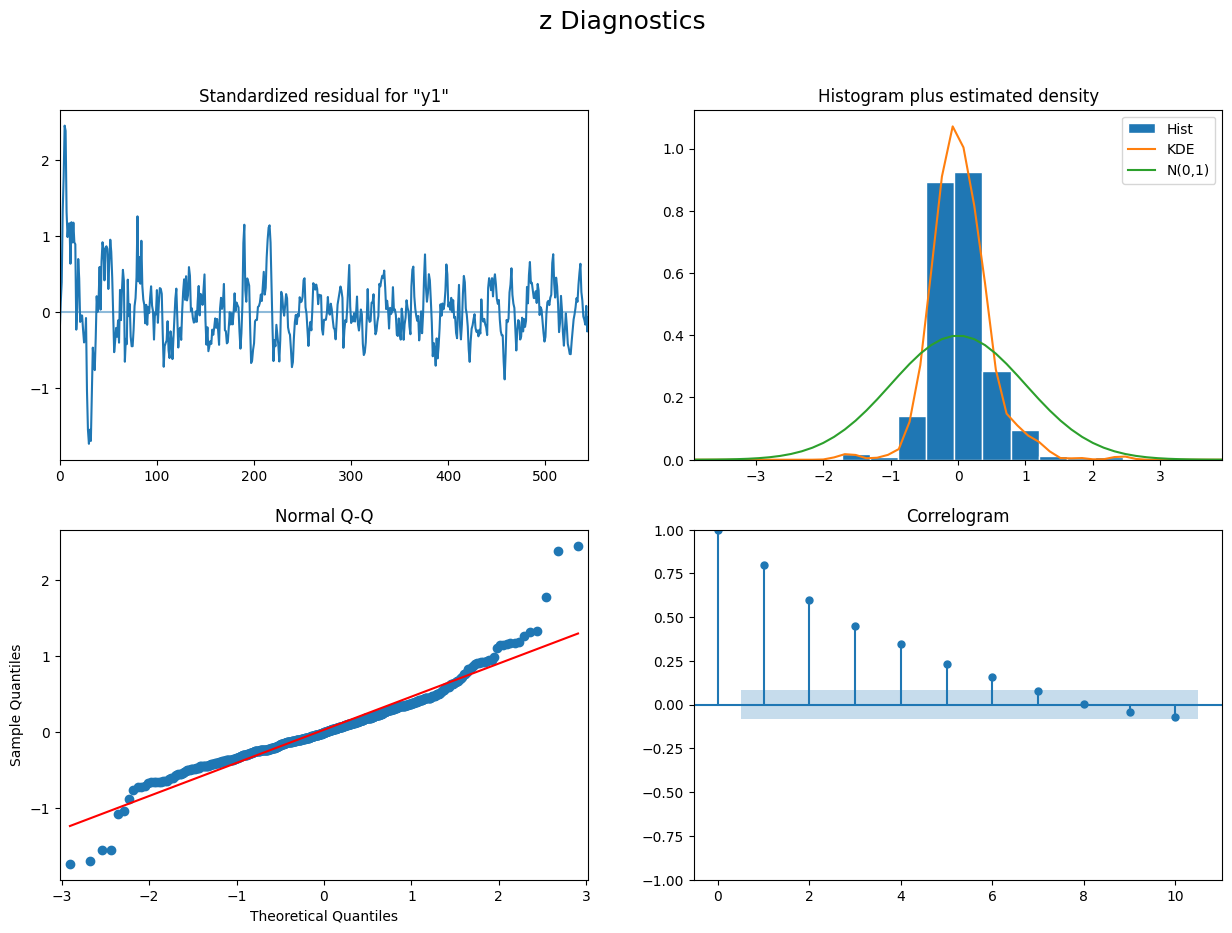

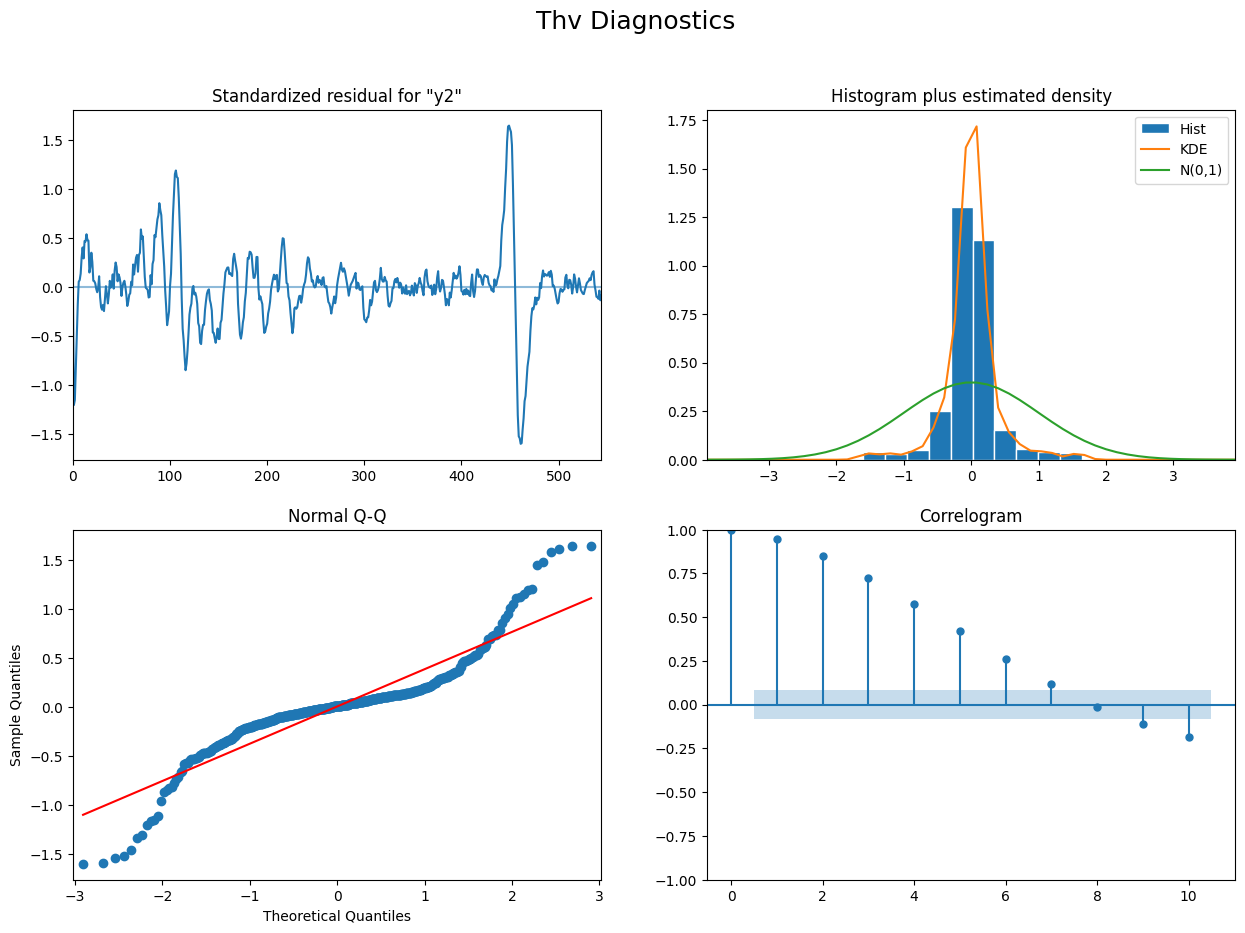

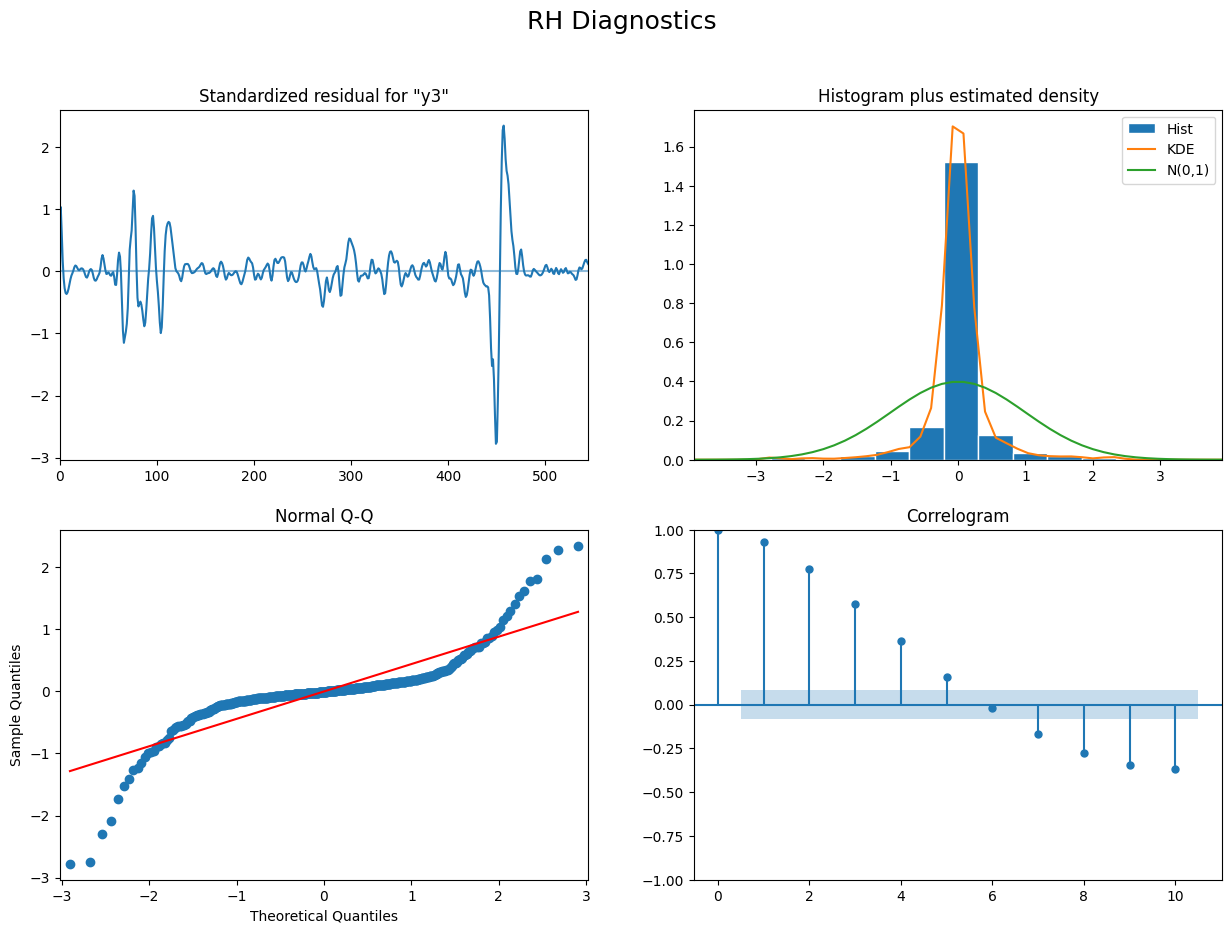

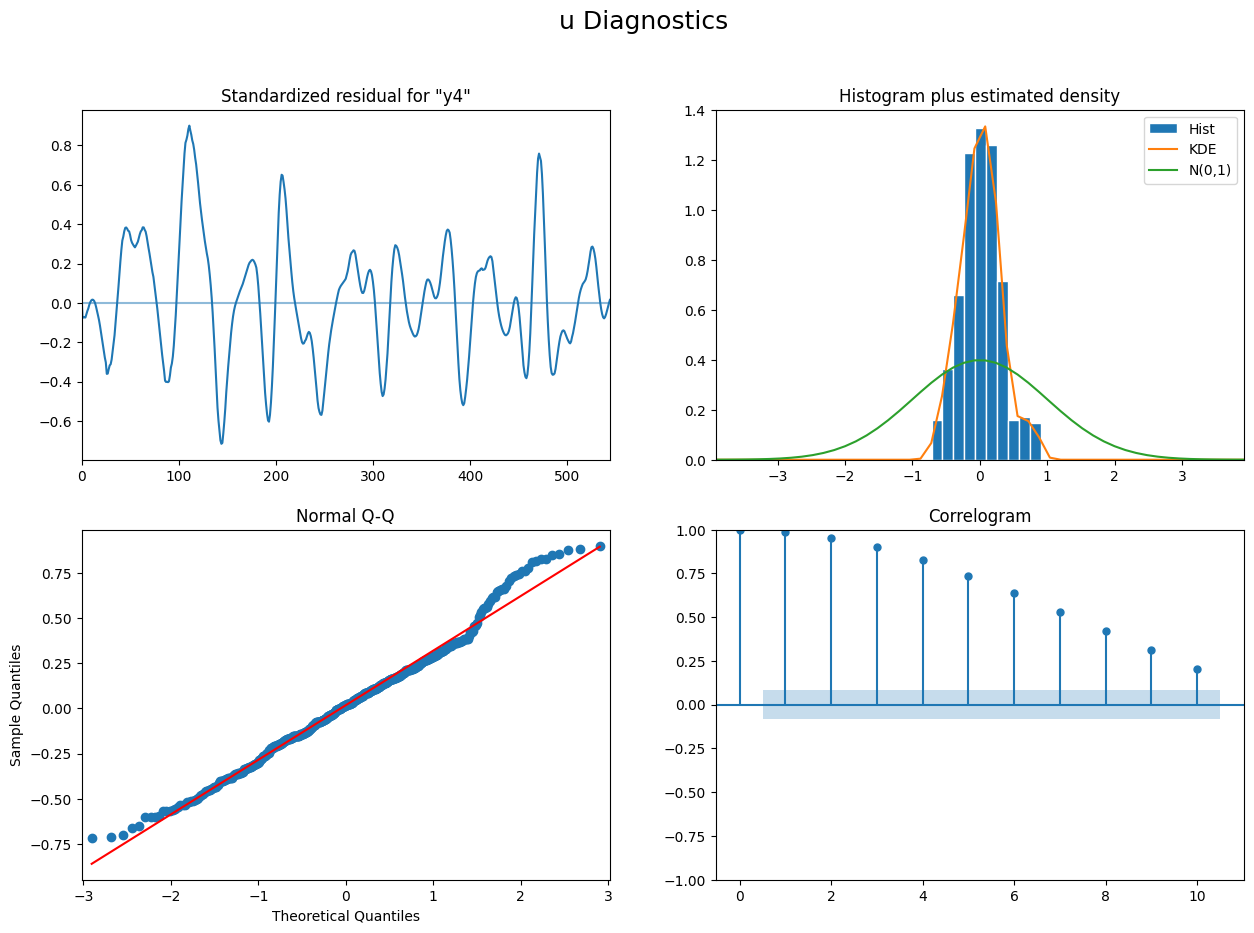

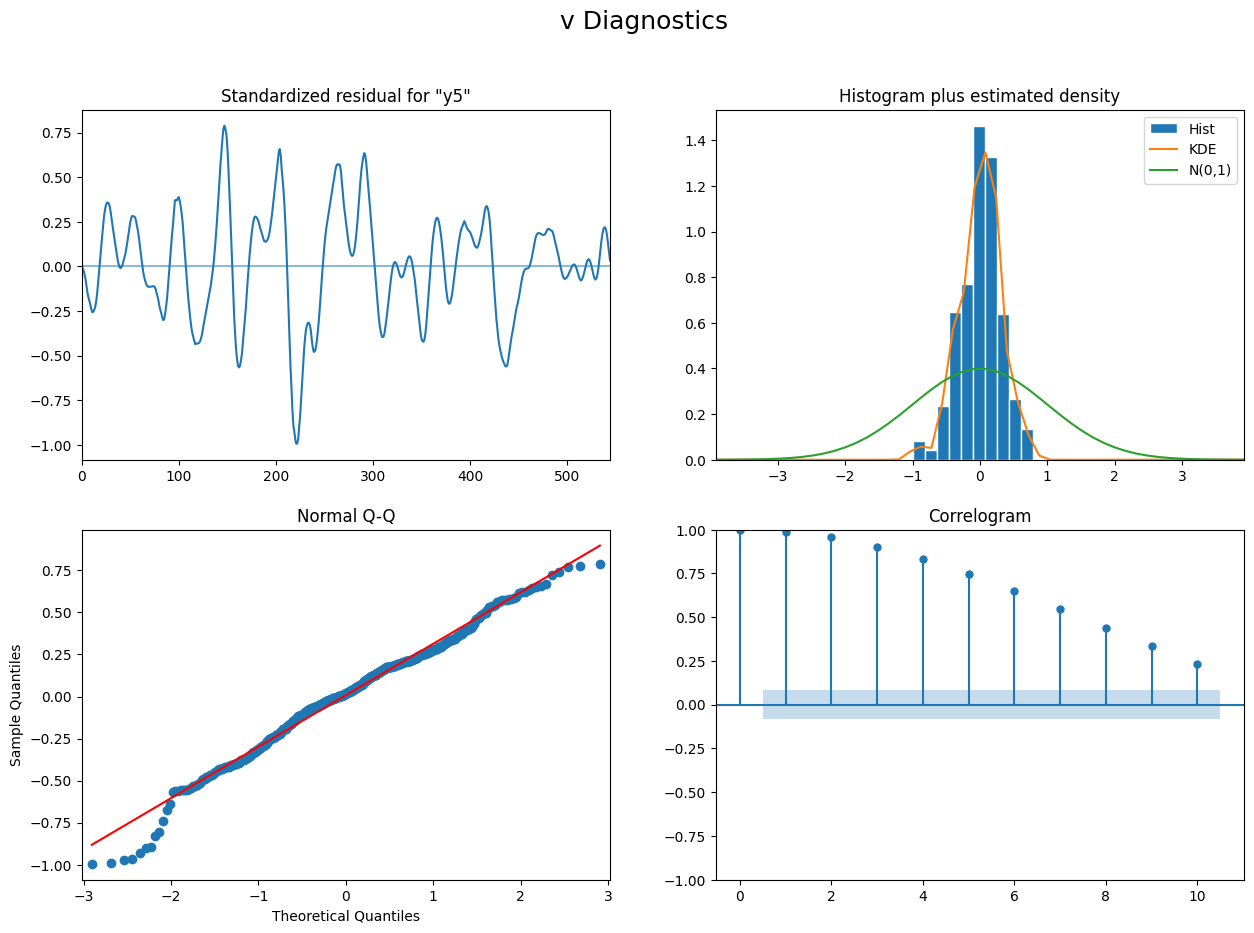

In [10]:
# - Create diagnostic figures based on standardized residuals:
#   (1) time series graph
#   (2) histogram
#   (3) Q-Q plot
#   (4) correlogram
for var in range(5):
    fig=results.plot_diagnostics(variable=var)
    fig.set_size_inches(15,10)
    fig.suptitle(f'{variables[var]} Diagnostics', fontsize=18)
    plt.show(block=True)

In [12]:
normal=results.test_normality('jarquebera')[:,1]>0.001
print(normal)

[False False False  True False]


In [13]:
homoskedastic=results.test_heteroskedasticity('breakvar')[:,1]>0.001
print(homoskedastic)

[False  True False False False]


In [19]:
l1_uncorrelated=results.test_serial_correlation('ljungbox')[:,1,0]>0.001
print(l1_uncorrelated)

[False False False False False]


In [22]:
normality_tests=[]
homoskedasticity_tests=[]
l1_uncorrelation_tests=[]

for i in tqdm(range(10)):
    pid, gdp = next(iterator)
    data=gdp.data
    endog, measurement_var=data_prep(data)
    model = LocalLinearTrend(endog=endog, measurement_var=measurement_var)
    try:
        results = model.fit(method='powell',
                    maxiter=100,
                    full_output=1,
                    disp=5)
        normality_tests.append(results.test_normality('jarquebera')[:,1]>0.001)
        homoskedasticity_tests.append(results.test_heteroskedasticity('breakvar')[:,1]>0.001)
        l1_uncorrelation_tests.append(results.test_serial_correlation('ljungbox')[:,1,0]>0.001)
    except:
        pass
    

  0%|          | 0/10 [00:00<?, ?it/s]

Optimization terminated successfully.
         Current function value: 6.696456
         Iterations: 6
         Function evaluations: 975


 10%|█         | 1/10 [00:46<06:55, 46.21s/it]

Optimization terminated successfully.
         Current function value: 6.826267
         Iterations: 3
         Function evaluations: 431


 20%|██        | 2/10 [01:01<03:43, 27.99s/it]

...

 80%|████████  | 8/10 [03:54<01:08, 34.12s/it]

         Current function value: nan
         Iterations: 1
         Function evaluations: 31


c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
 90%|█████████ | 9/10 [03:56<00:24, 24.01s/it]

         Current function value: nan
         Iterations: 1
         Function evaluations: 31


c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
100%|██████████| 10/10 [03:59<00:00, 23.91s/it]


In [21]:
normality_tests

[array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.79241716e-16,
        6.30247955e-55]),
 array([1.28458376e-307, 0.00000000e+000, 0.00000000e+000, 1.00286126e-005,
        1.19753691e-078])]

In [15]:
homoskedasticity_tests

[array([False,  True, False, False, False]),
 array([False,  True, False, False, False]),
 array([False,  True, False, False, False]),
 array([False,  True, False, False, False]),
 array([False,  True, False, False, False]),
 array([False,  True, False, False, False]),
 array([False,  True, False, False, False]),
 array([False,  True, False, False, False]),
 array([False,  True, False, False, False]),
 array([False,  True, False, False, False])]

In [16]:
l1_uncorrelation_tests

[array([False, False, False, False, False]),
 array([False, False, False, False, False]),
 array([False, False, False, False, False]),
 array([False, False, False, False, False]),
 array([False, False, False, False, False]),
 array([False, False, False, False, False]),
 array([False, False, False, False, False]),
 array([False, False, False, False, False]),
 array([False, False, False, False, False]),
 array([False, False, False, False, False])]

## Univariate Local Linear Trend with Free Measurement Unc.

In [25]:
"""
Univariate Local Linear Trend Model
"""

class UnivariateLocalLinearTrend(sm.tsa.statespace.MLEModel):
    def __init__(self, endog):
        # Model order
        k_states = k_posdef = 2

        # Initialize the statespace
        super(UnivariateLocalLinearTrend, self).__init__(
            endog,
            k_states=k_states,
            k_posdef=k_posdef,
            initialization="approximate_diffuse",
            loglikelihood_burn=k_states,
        )

        # Initialize the matrices
        self.ssm["design"] = np.array([1, 0])
        self.ssm["transition"] = np.array([[1, 1], [0, 1]])
        self.ssm["selection"] = np.eye(k_states)

        # Cache some indices
        self._state_cov_idx = ("state_cov",) + np.diag_indices(k_posdef)

    @property
    def param_names(self):
        return ["sigma2.measurement", "sigma2.level", "sigma2.trend"]

    @property
    def start_params(self):
        return [np.std(self.endog)] * 3

    def transform_params(self, unconstrained):
        return unconstrained**2

    def untransform_params(self, constrained):
        return constrained**0.5

    def update(self, params, *args, **kwargs):
        params = super(UnivariateLocalLinearTrend, self).update(params, *args, **kwargs)

        # Observation covariance
        self.ssm["obs_cov", 0, 0] = params[0]

        # State covariance
        self.ssm[self._state_cov_idx] = params[1:]

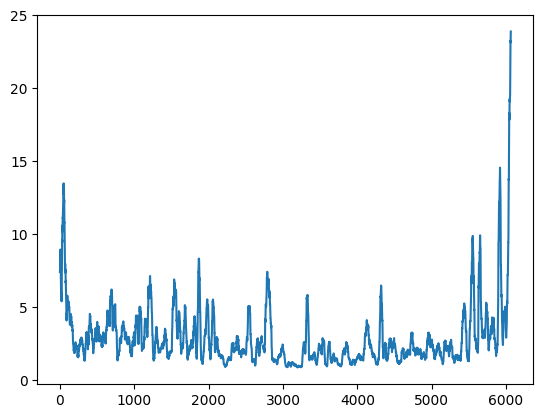

In [37]:
plt.plot(u_var)

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                 6065
Model:             UnivariateLocalLinearTrend   Log Likelihood               -9890.437
Date:                        Thu, 20 Aug 2026   AIC                          19786.874
Time:                                17:02:41   BIC                          19807.004
Sample:                                     0   HQIC                         19793.861
                                       - 6065                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement     0.0861      0.016      5.481      0.000       0.055       0.117
sigma2.level           1.2969      0.038   

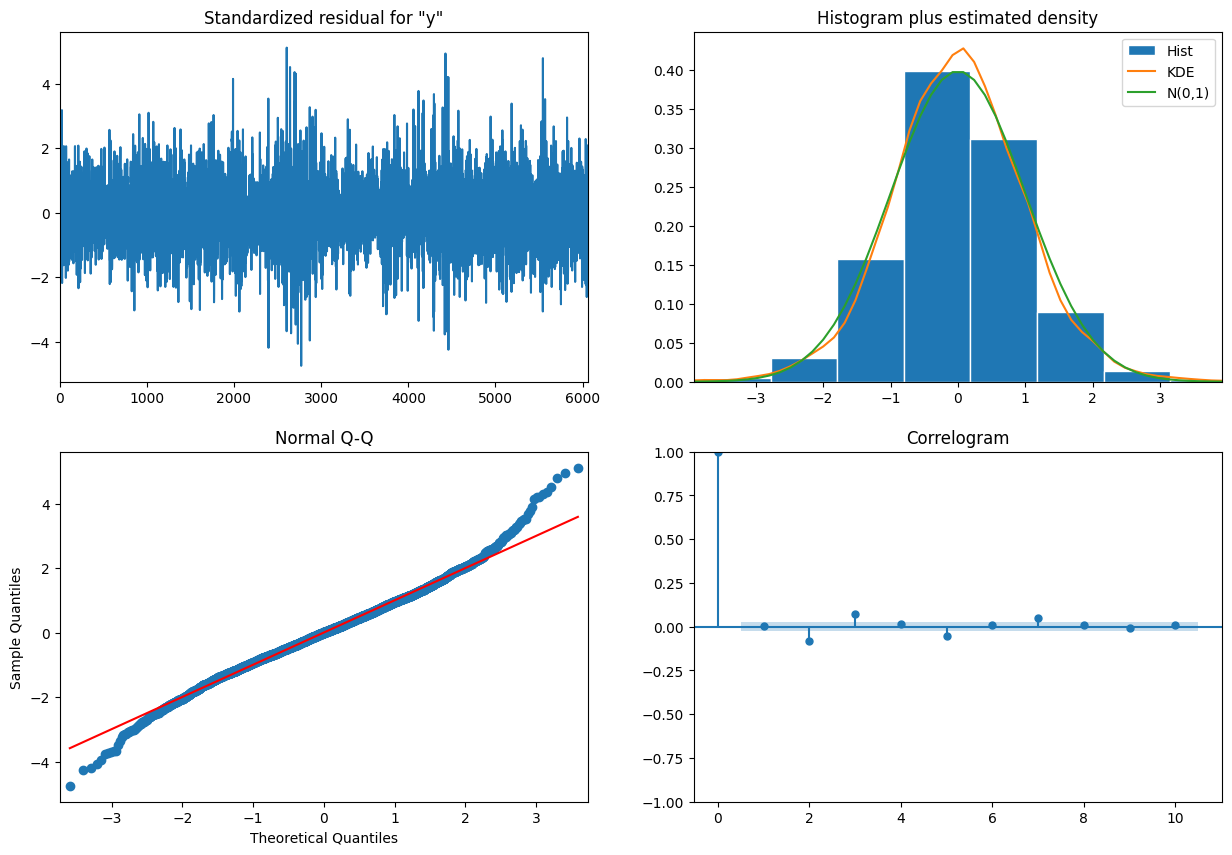

In [26]:
mod = UnivariateLocalLinearTrend(z)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

No more autocorrelated but still not normal and heteroskedastic.

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3160: UserWarning: Early subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3160: UserWarning: Later subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(


                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                 6065
Model:             UnivariateLocalLinearTrend   Log Likelihood                     nan
Date:                        Thu, 20 Aug 2026   AIC                                nan
Time:                                17:04:46   BIC                                nan
Sample:                                     0   HQIC                               nan
                                       - 6065                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement        nan        nan        nan        nan         nan         nan
sigma2.level              nan        nan   

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

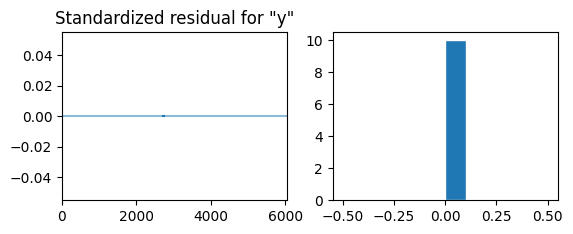

In [27]:
mod = UnivariateLocalLinearTrend(Thv)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

As before.

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood                -579.192
Date:                        Thu, 20 Aug 2026   AIC                           1164.384
Time:                                10:54:43   BIC                           1177.773
Sample:                                     0   HQIC                          1169.580
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement     0.0070      0.003      2.031      0.042       0.000       0.014
sigma2.level        3.129e-11      0.014   

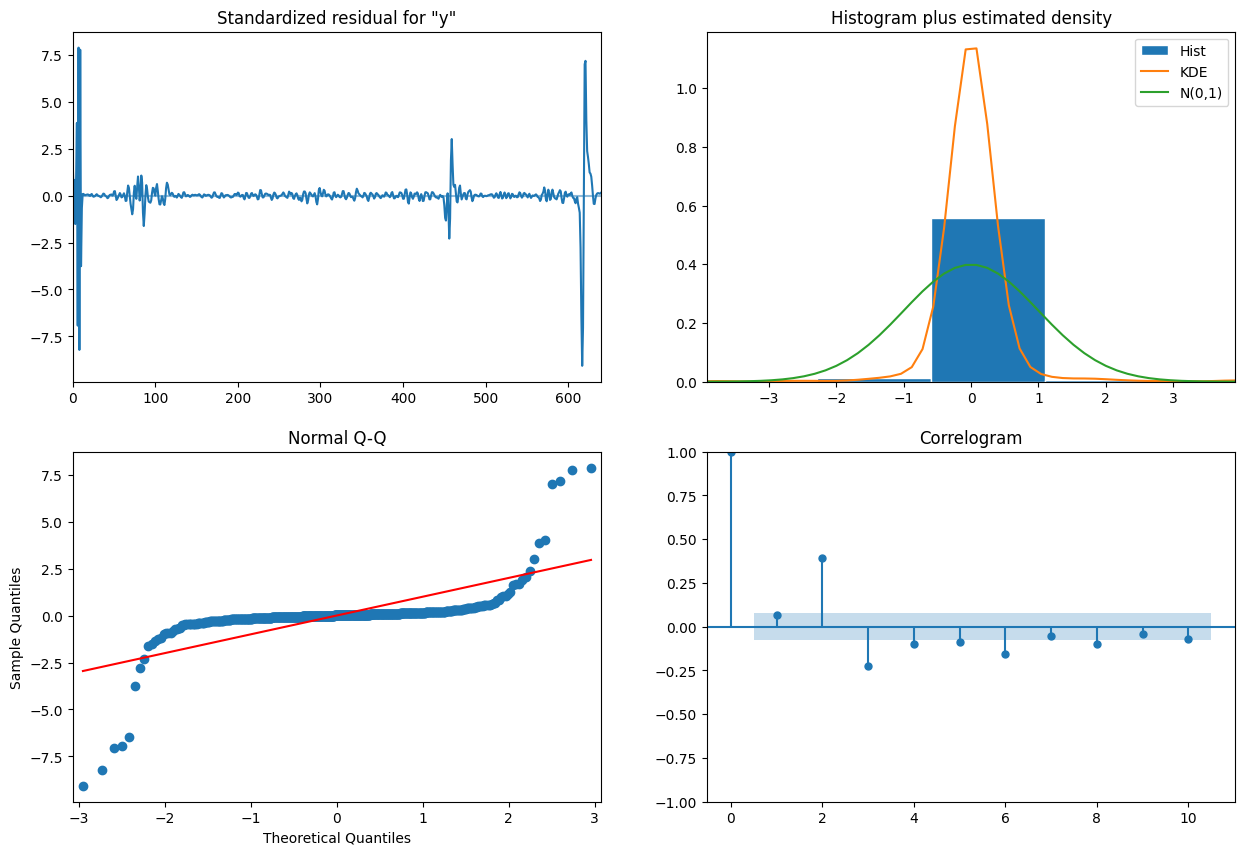

In [12]:
mod = UnivariateLocalLinearTrend(RH)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood                 916.351
Date:                        Thu, 20 Aug 2026   AIC                          -1826.701
Time:                                10:55:12   BIC                          -1813.312
Sample:                                     0   HQIC                         -1821.505
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement     0.0006   3.47e-05     17.430      0.000       0.001       0.001
sigma2.level        1.873e-11      0.000   

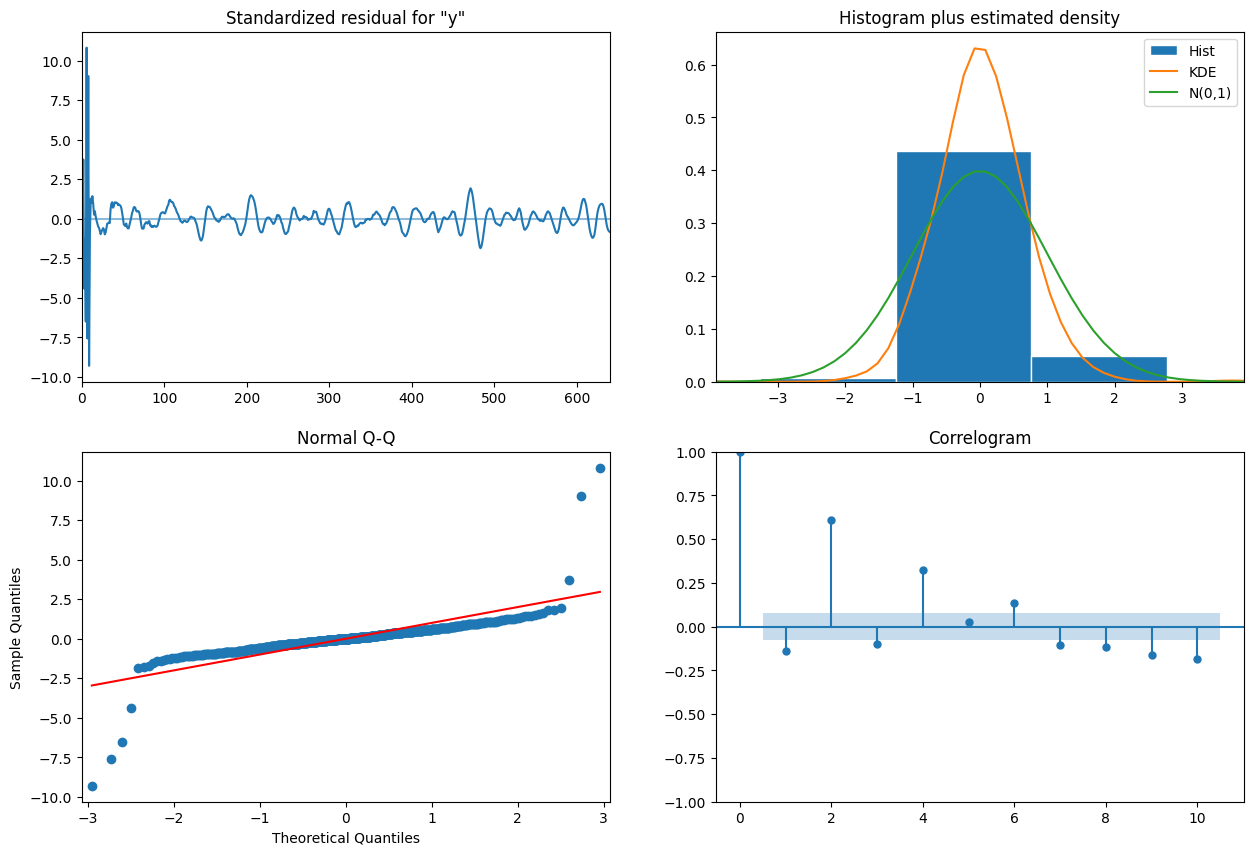

In [13]:
mod = UnivariateLocalLinearTrend(u)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood                1544.419
Date:                        Thu, 20 Aug 2026   AIC                          -3082.837
Time:                                10:55:25   BIC                          -3069.448
Sample:                                     0   HQIC                         -3077.641
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement   1.24e-11   2.86e-05   4.33e-07      1.000   -5.61e-05    5.61e-05
sigma2.level         8.76e-11   9.69e-05   

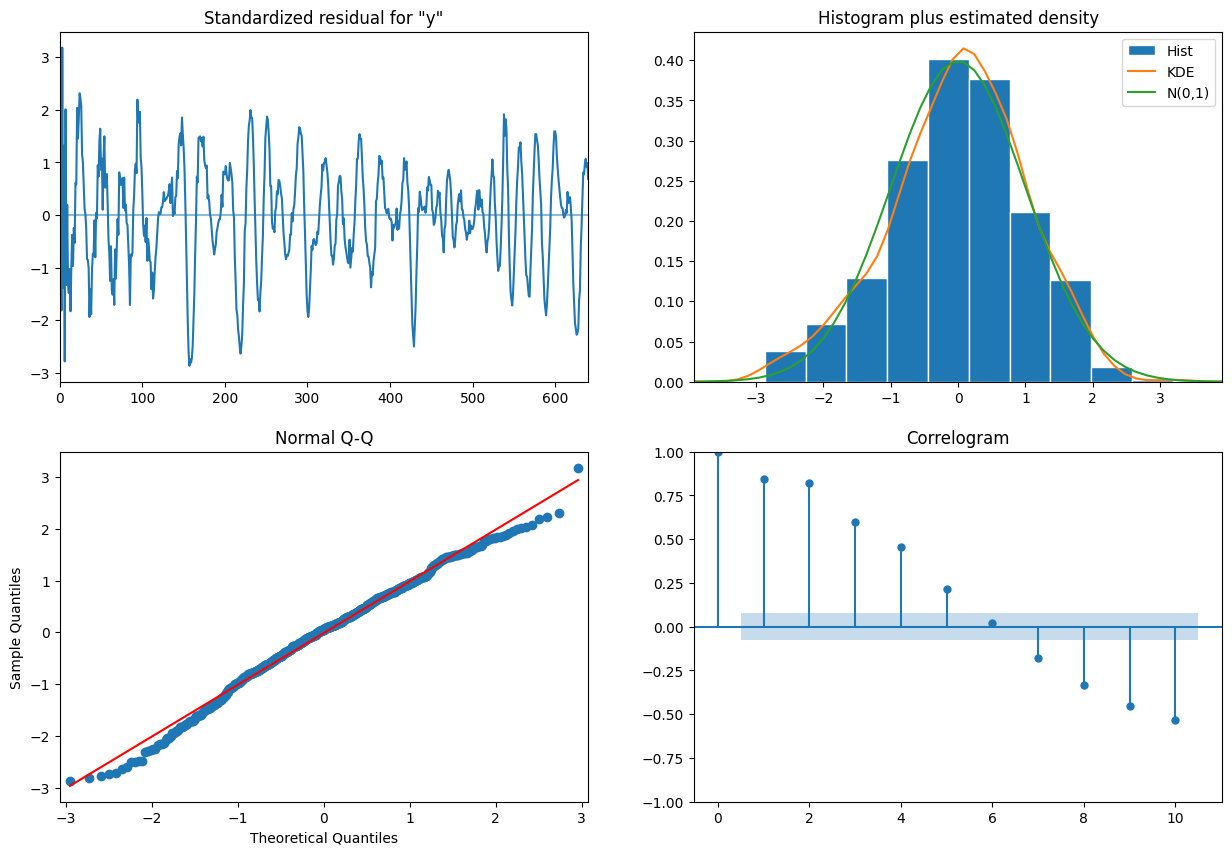

In [14]:
mod = UnivariateLocalLinearTrend(v)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

## Local Linear Level with GRUAN measurement unc.

In [15]:
# Setup the model
model = MeasurementLocalLevel(endog=endog, measurement_var=measurement_var,
                         measurement_names=['alt', 'temp', 'rh', 'u', 'v'])

# Fit it using MLE with a fixed sequence of measurement variances
results = model.fit(method='powell',
            maxiter=100,
            full_output=1,
            disp=5)

Optimization terminated successfully.
         Current function value: 8.413188
         Iterations: 3
         Function evaluations: 203


In [16]:
# - Print a table summarizing estimation results
print(results.summary())


                                 Statespace Model Results                                 
Dep. Variable:     ['y1', 'y2', 'y3', 'y4', 'y5']   No. Observations:                  643
Model:                      MeasurementLocalLevel   Log Likelihood               -5409.680
Date:                            Thu, 20 Aug 2026   AIC                          10829.359
Time:                                    10:58:07   BIC                          10851.651
Sample:                                         0   HQIC                         10838.013
                                            - 643                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
alt_sigma2.level     47.5582     17.920      2.654      0.008      12.436      82.680
temp_sigma2.le

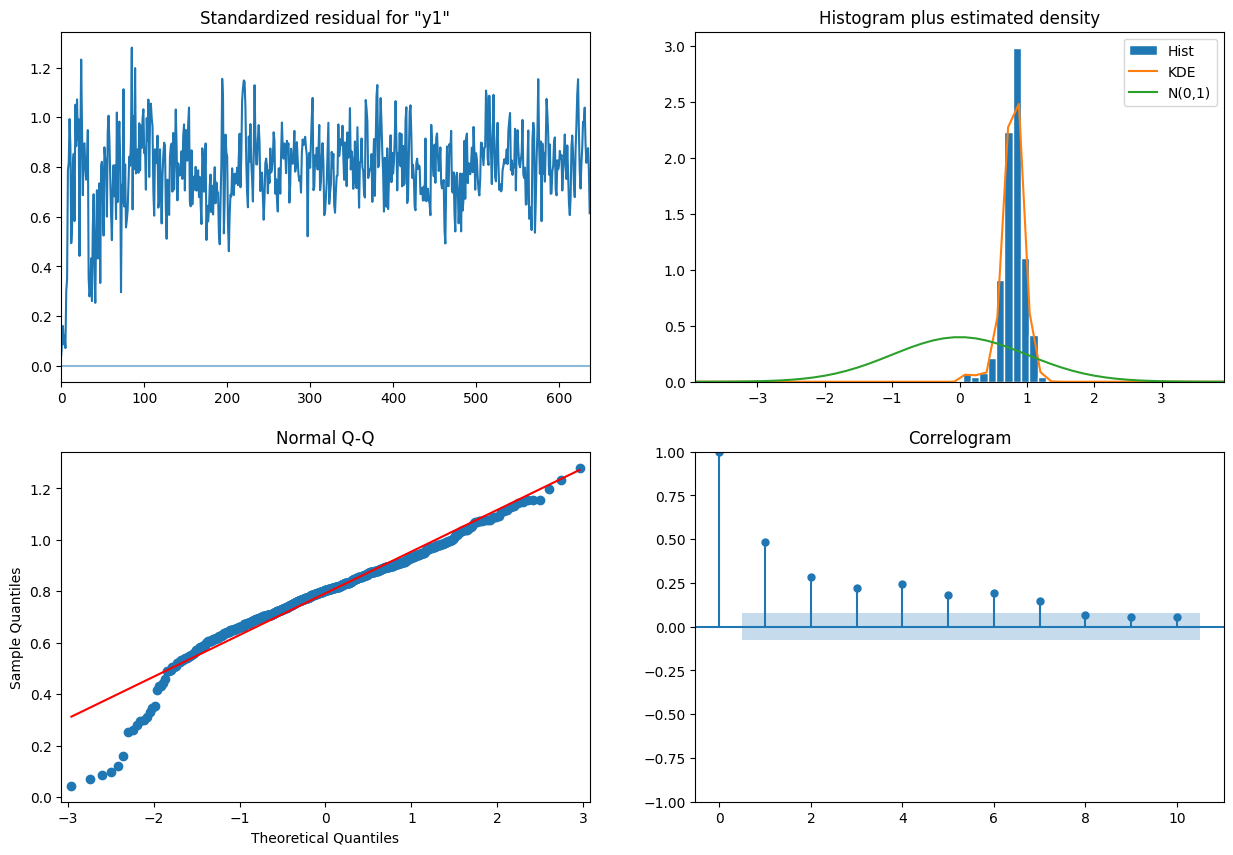

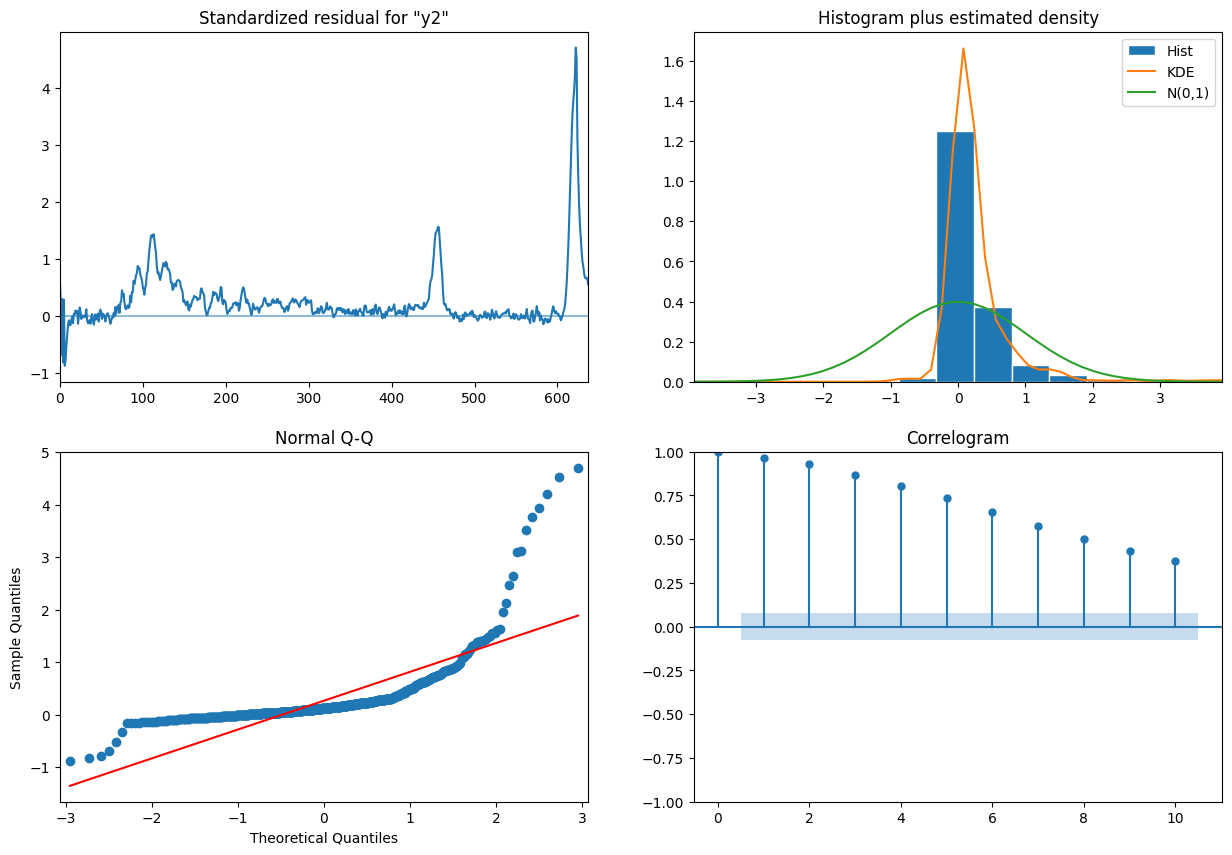

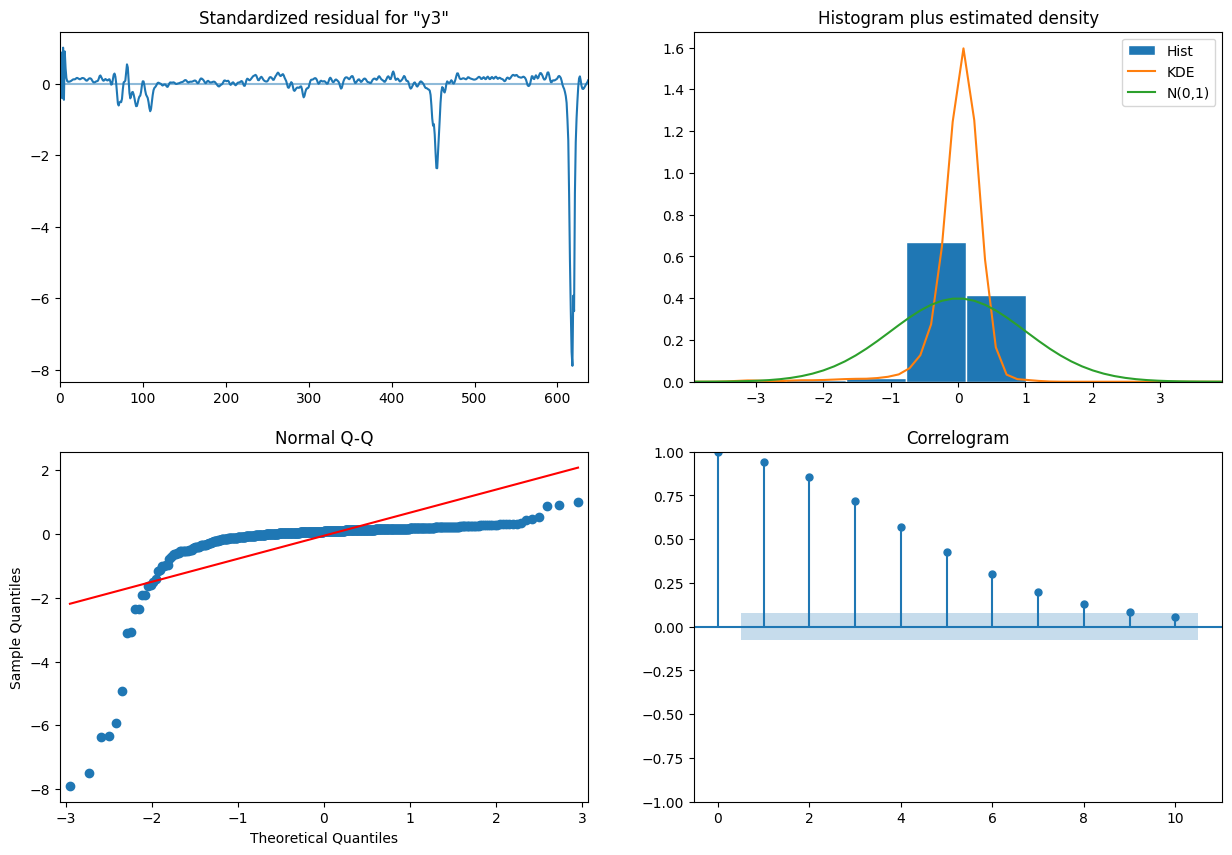

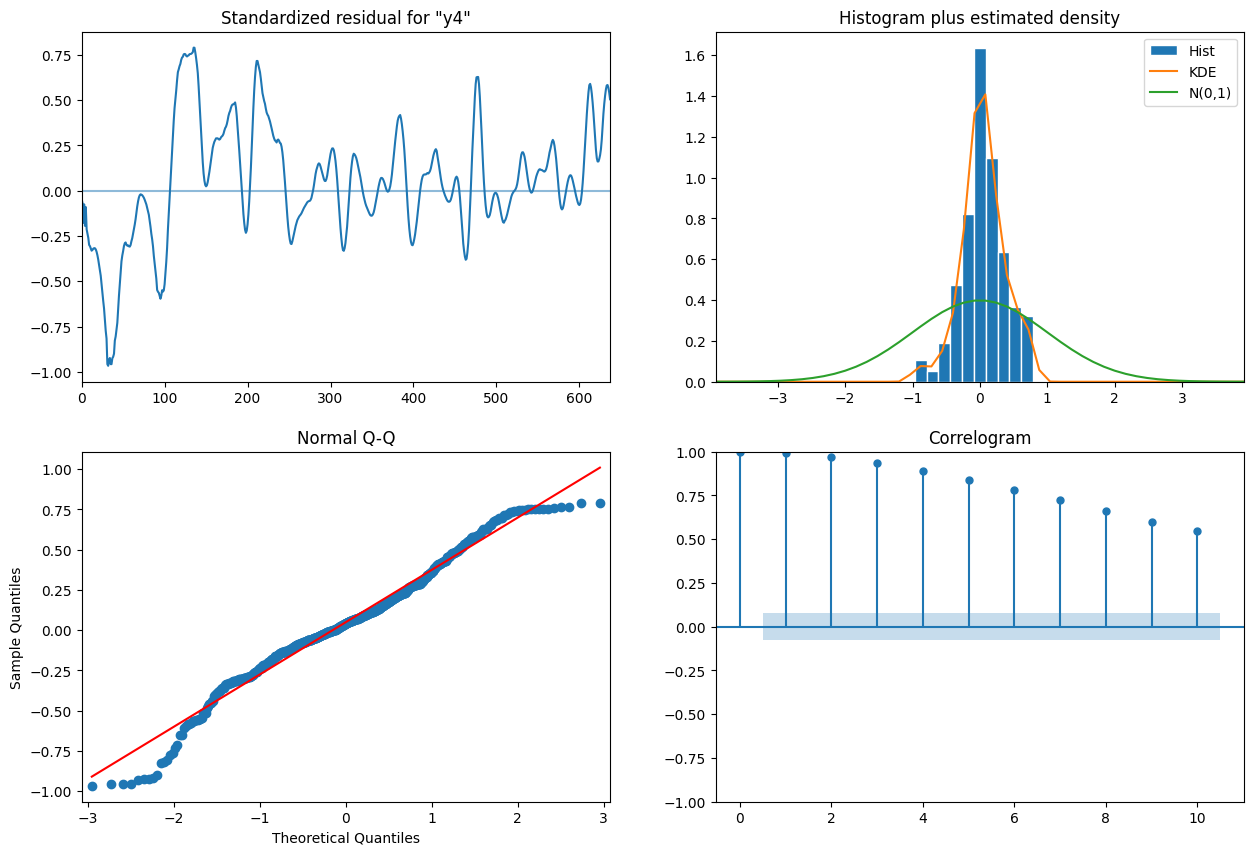

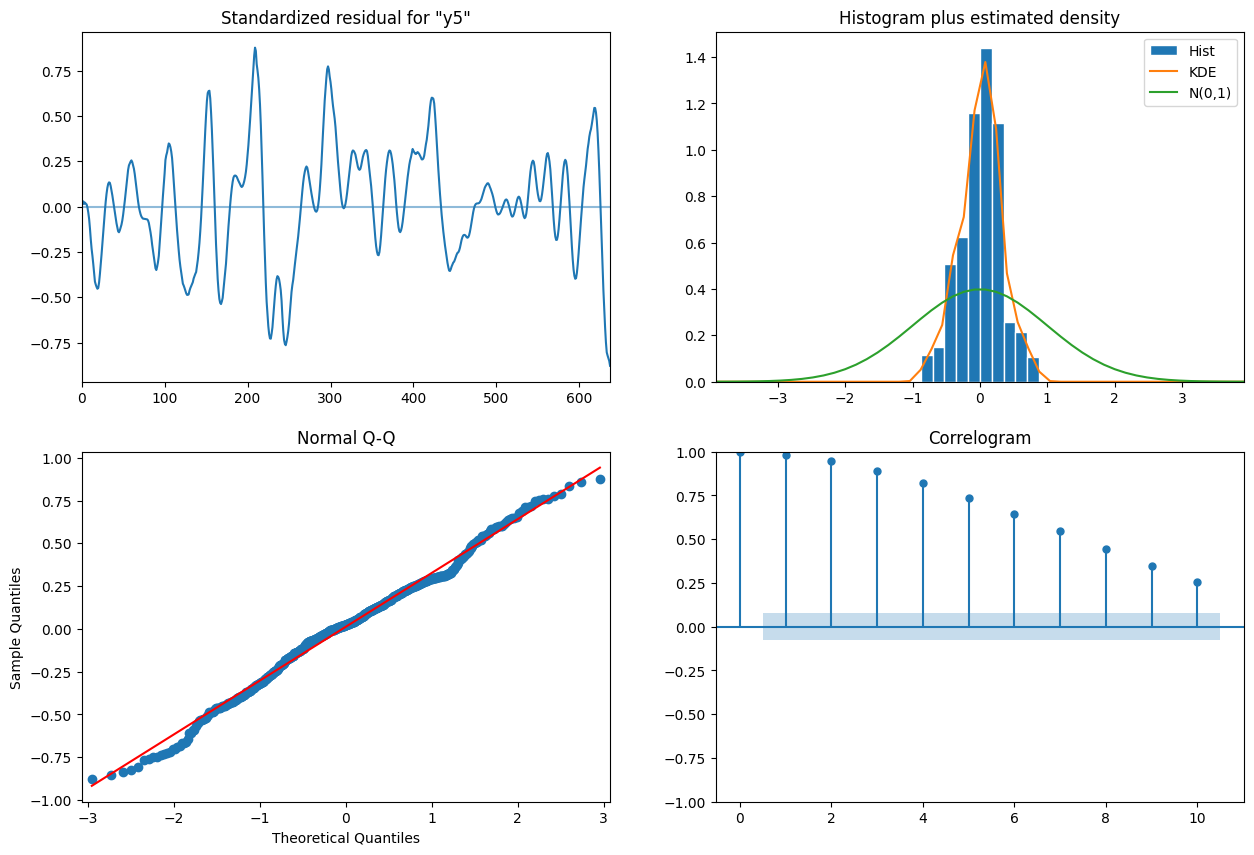

In [17]:
# - Create diagnostic figures based on standardized residuals:
#   (1) time series graph
#   (2) histogram
#   (3) Q-Q plot
#   (4) correlogram
for var in range(5):
    fig=results.plot_diagnostics(variable=var)
    fig.set_size_inches(15,10)
    plt.show(block=True)

## VARMAX

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:373: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                 Statespace Model Results                                 
Dep. Variable:     ['y1', 'y2', 'y3', 'y4', 'y5']   No. Observations:                  100
Model:                                 VARMA(2,2)   Log Likelihood               -2969.591
                                      + intercept   AIC                           6159.181
Date:                            Thu, 20 Aug 2026   BIC                           6445.750
Time:                                    11:02:10   HQIC                          6275.161
Sample:                                         0                                         
                                            - 100                                         
Covariance Type:                              opg                                         
Ljung-Box (L1) (Q):     58.88, 96.89, 89.26, 98.41, 98.11   Jarque-Bera (JB):    3.01, 13.28, 17.00, 5.09, 9.05
Prob(Q):                     0.00, 0.00, 0.00, 0.00, 0.00   Prob(JB):

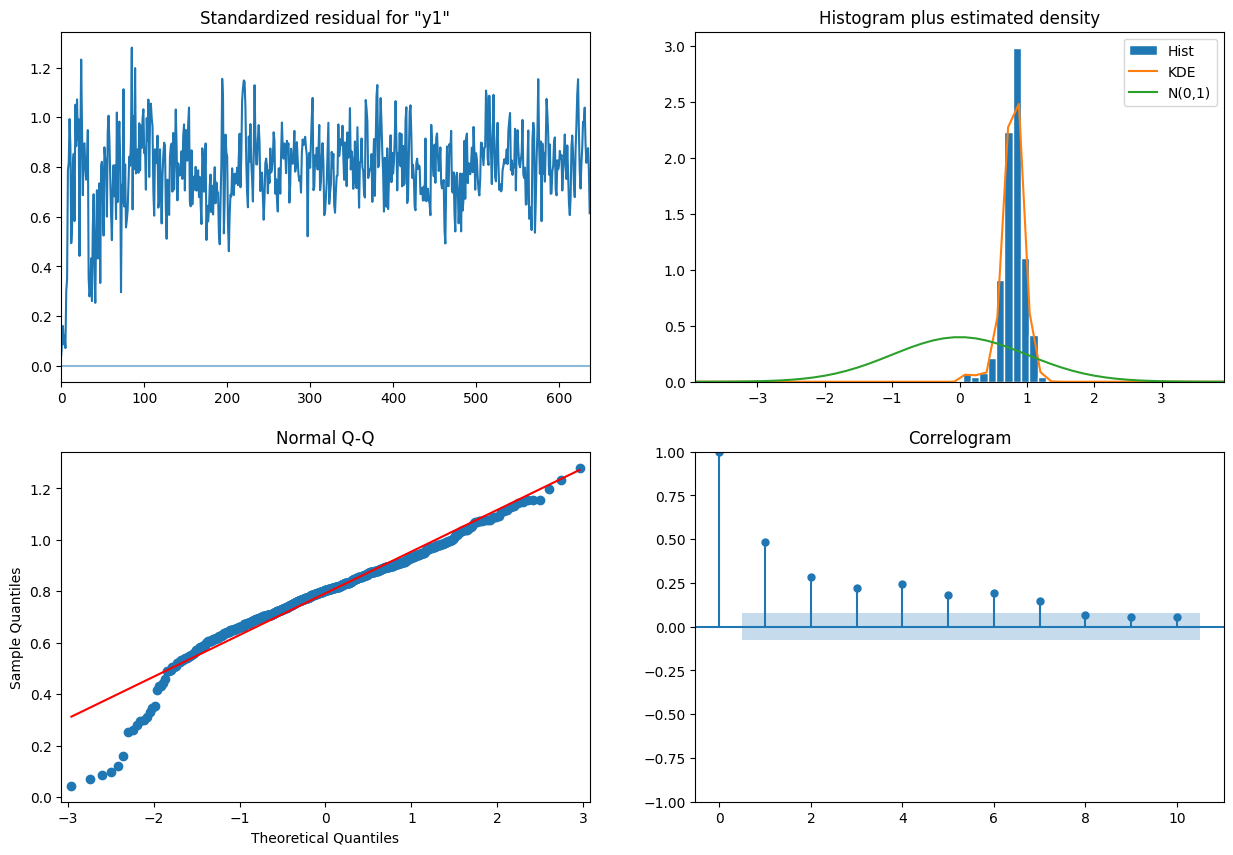

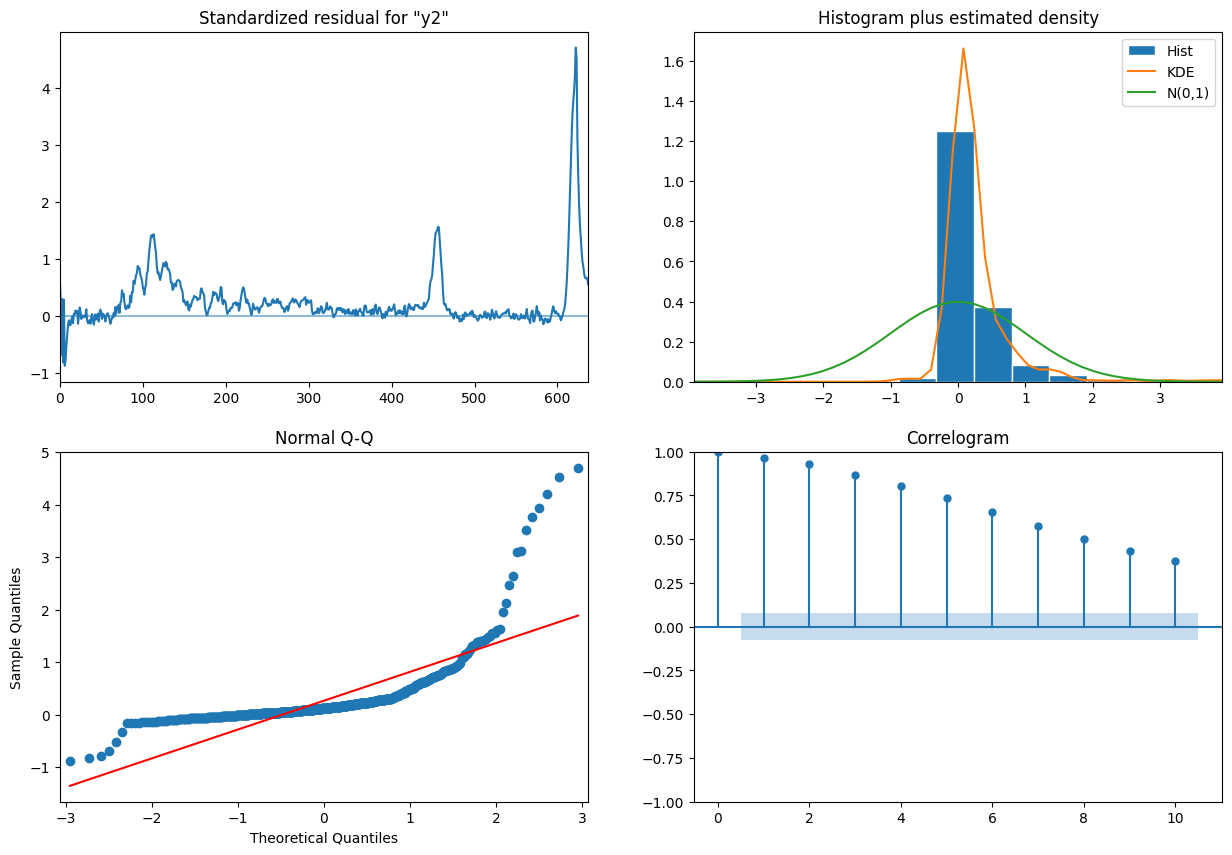

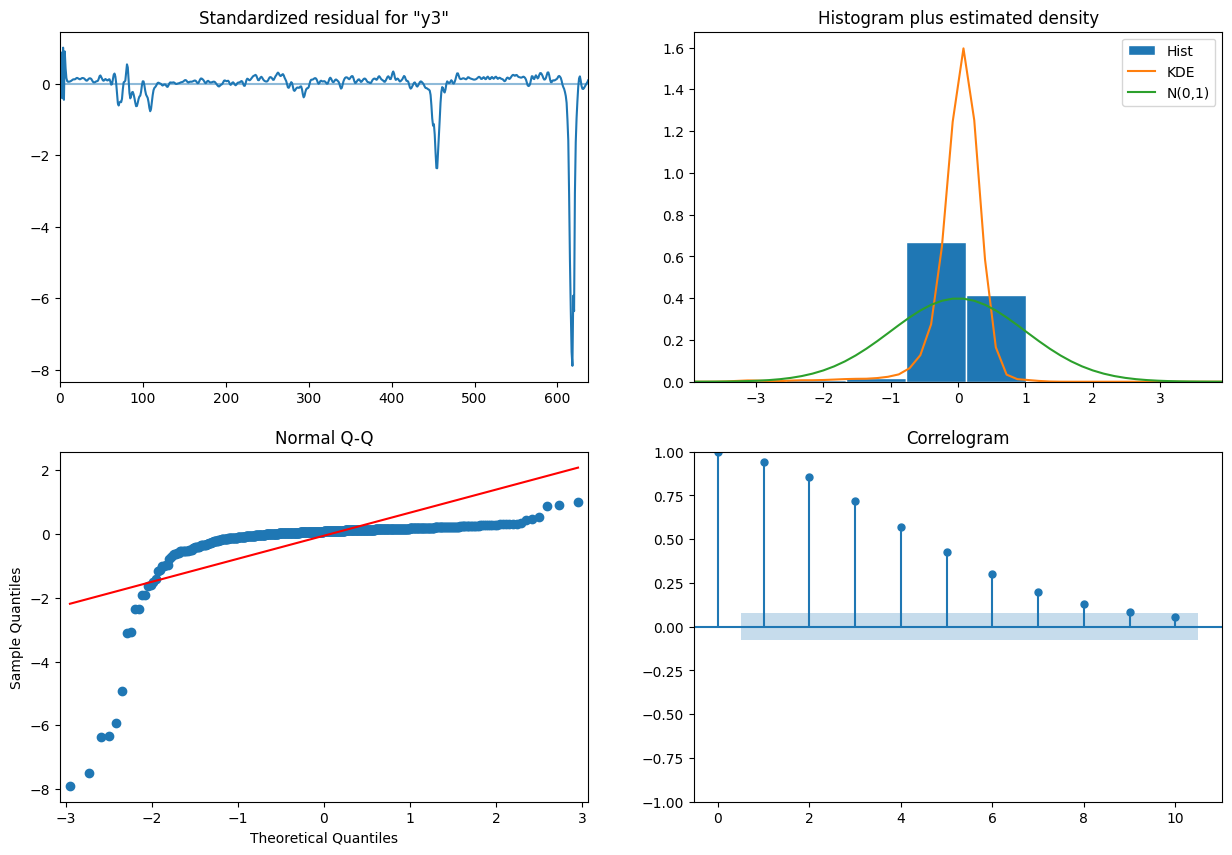

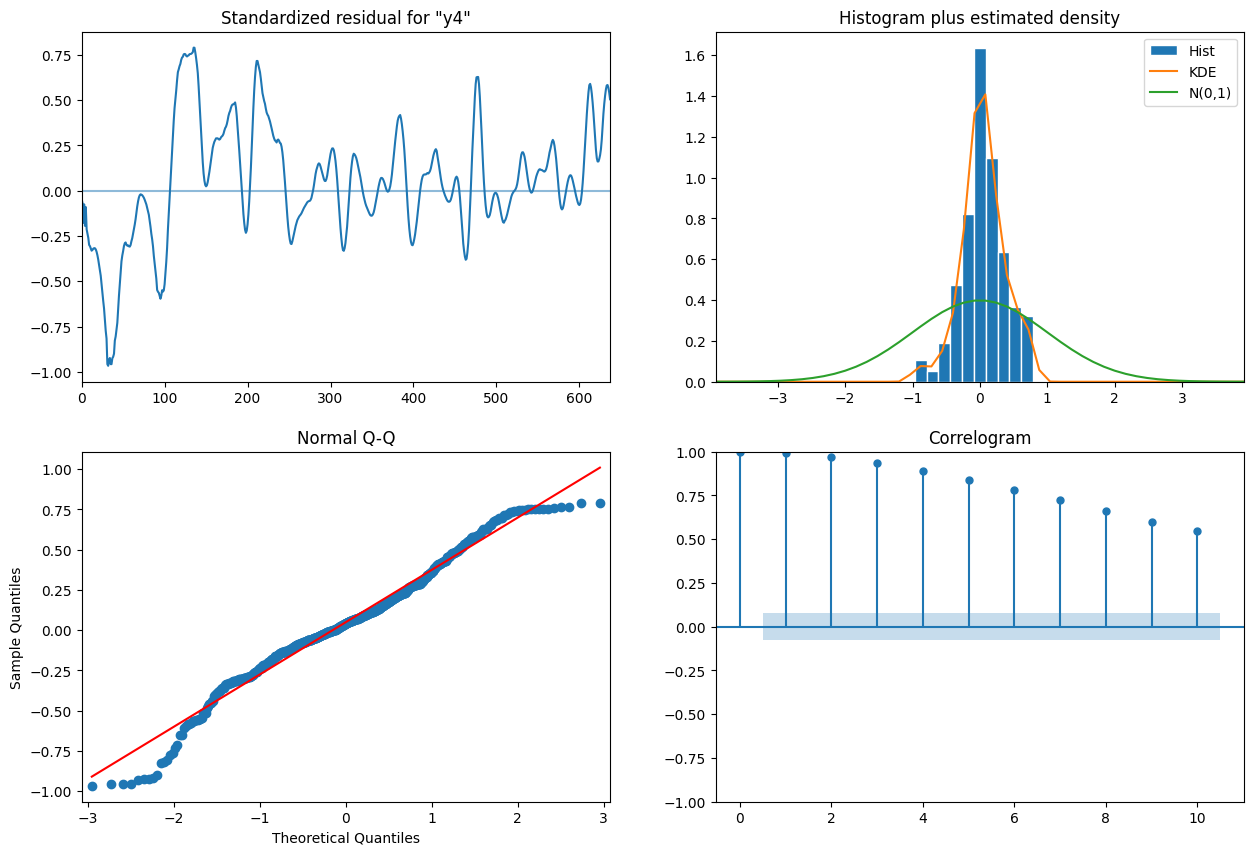

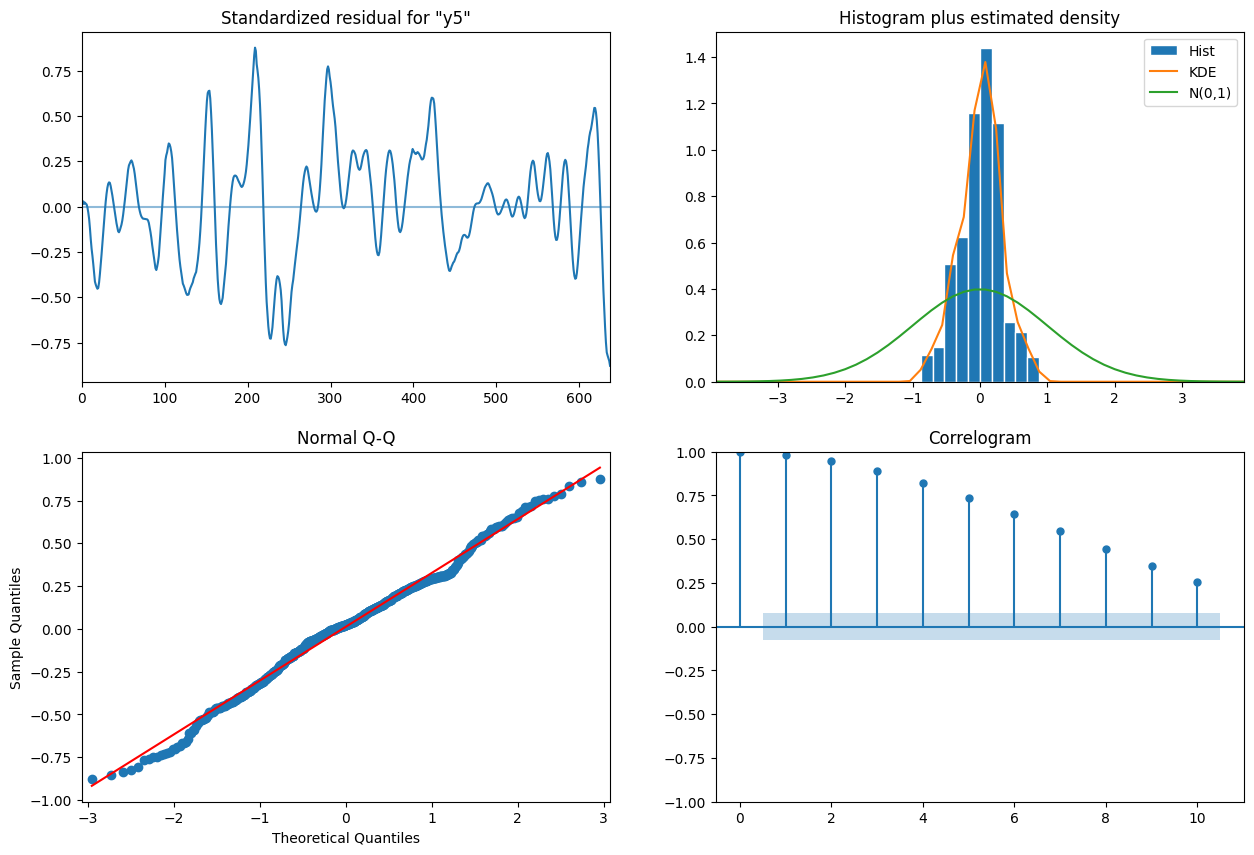

In [18]:
mod =sm.tsa.VARMAX(endog[:100], order=(2,2), error_cov_type='diagonal')

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
for i in range(5):
    fig=results.plot_diagnostics(i)
    fig.set_size_inches(15,10)
    plt.show(block=True)


## SARIMAX

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1032.076
Date:                Thu, 20 Aug 2026   AIC                           2072.151
Time:                        11:03:06   BIC                           2090.010
Sample:                             0   HQIC                          2079.082
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5437      0.127      4.280      0.000       0.295       0.793
ar.L1          0.8995      0.024     37.397      0.000       0.852       0.947
ma.L1         -0.7016      0.040    -17.346      0.0

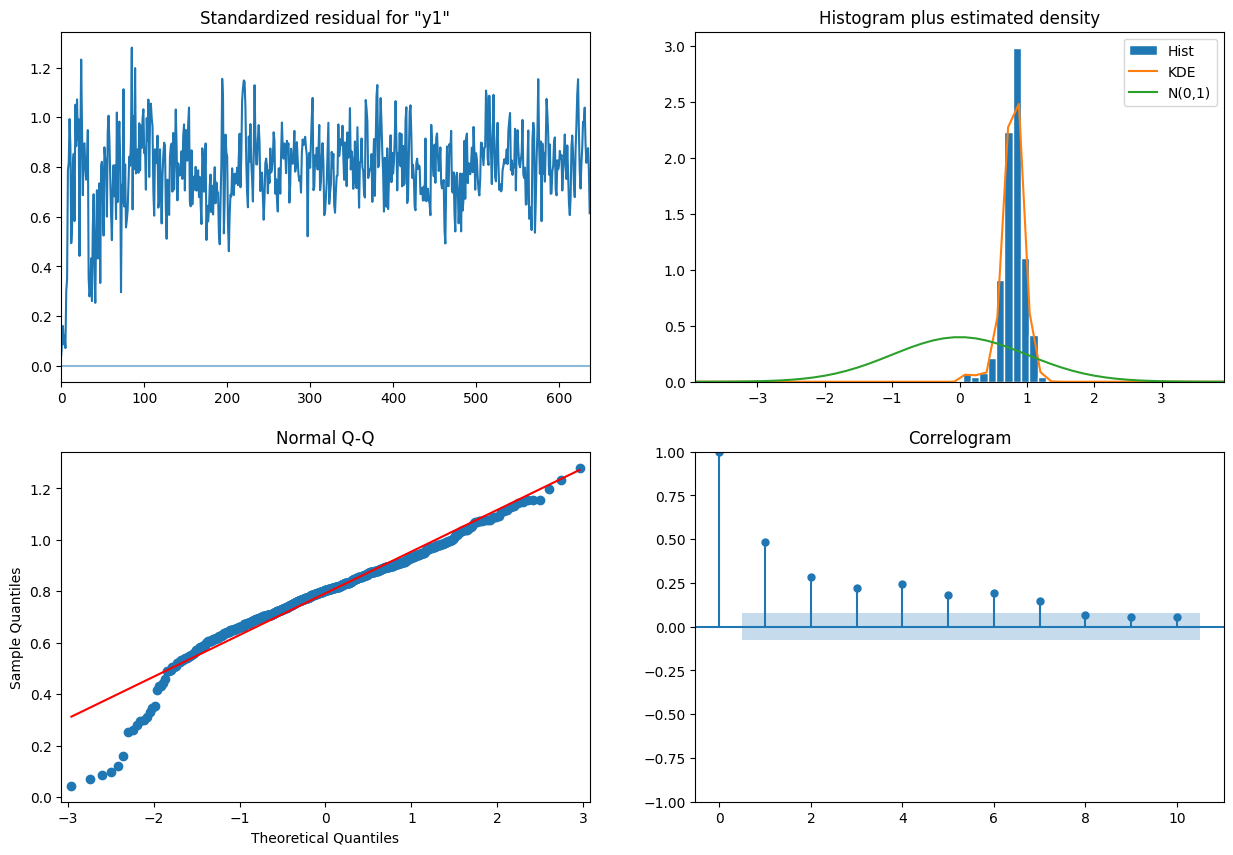

In [19]:
mod = sm.tsa.statespace.SARIMAX(z, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                1194.945
Date:                Thu, 20 Aug 2026   AIC                          -2381.890
Time:                        11:03:47   BIC                          -2364.031
Sample:                             0   HQIC                         -2374.959
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0017      0.001      1.786      0.074      -0.000       0.004
ar.L1          0.9502      0.008    119.789      0.000       0.935       0.966
ma.L1         -0.4534      0.013    -34.812      0.0

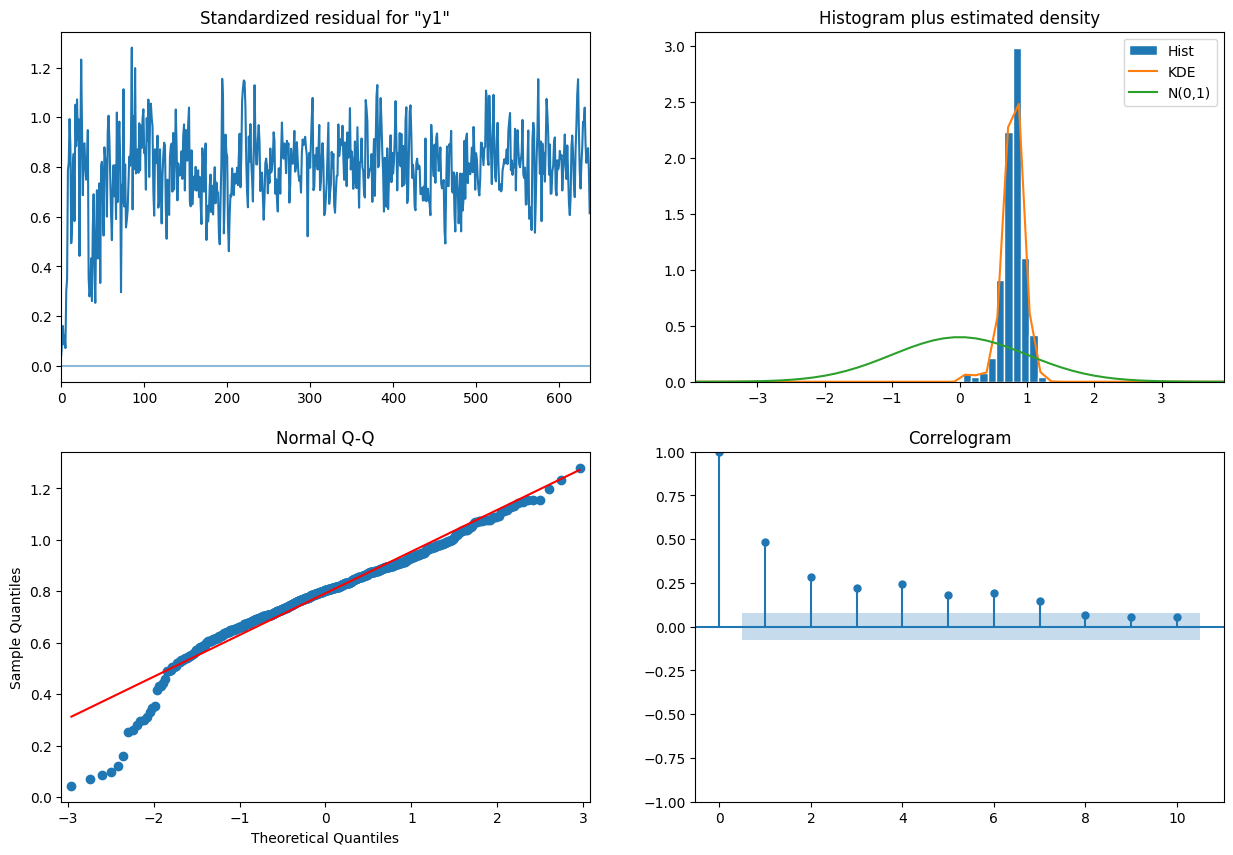

In [20]:
mod = sm.tsa.statespace.SARIMAX(Thv, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -566.693
Date:                Thu, 20 Aug 2026   AIC                           1141.387
Time:                        11:04:02   BIC                           1159.245
Sample:                             0   HQIC                          1148.317
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0120      0.029     -0.413      0.680      -0.069       0.045
ar.L1          0.8920      0.006    152.503      0.000       0.881       0.903
ma.L1          0.0035      0.009      0.412      0.6

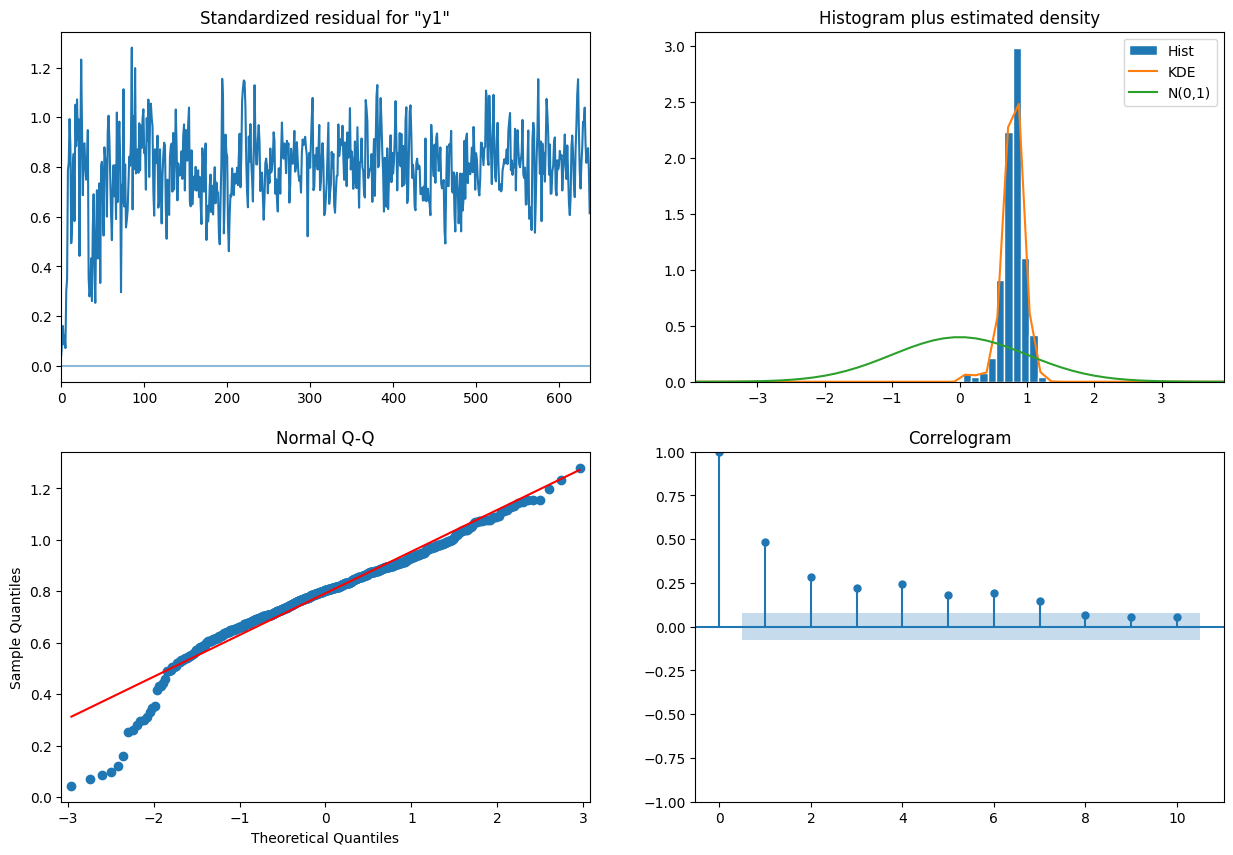

In [21]:
mod = sm.tsa.statespace.SARIMAX(RH, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 860.250
Date:                Thu, 20 Aug 2026   AIC                          -1712.499
Time:                        11:04:18   BIC                          -1694.641
Sample:                             0   HQIC                         -1705.568
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0007      0.002      0.389      0.697      -0.003       0.004
ar.L1          0.9570      0.015     62.395      0.000       0.927       0.987
ma.L1         -0.4475      0.025    -17.869      0.0

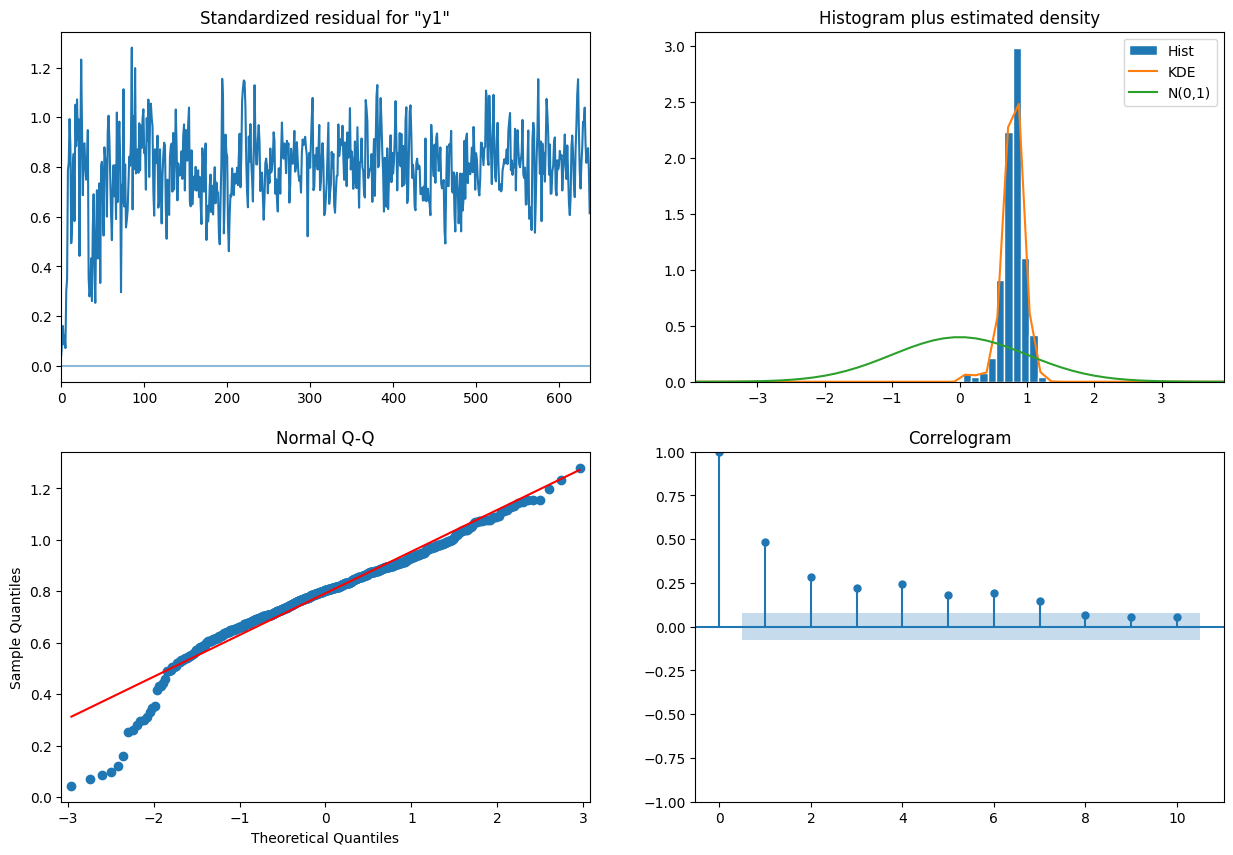

In [22]:
mod = sm.tsa.statespace.SARIMAX(u, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                1706.633
Date:                Thu, 20 Aug 2026   AIC                          -3405.265
Time:                        11:04:25   BIC                          -3387.407
Sample:                             0   HQIC                         -3398.335
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0001      0.001     -0.111      0.912      -0.002       0.002
ar.L1          0.9693      0.011     90.245      0.000       0.948       0.990
ma.L1          0.5031      0.016     31.808      0.0

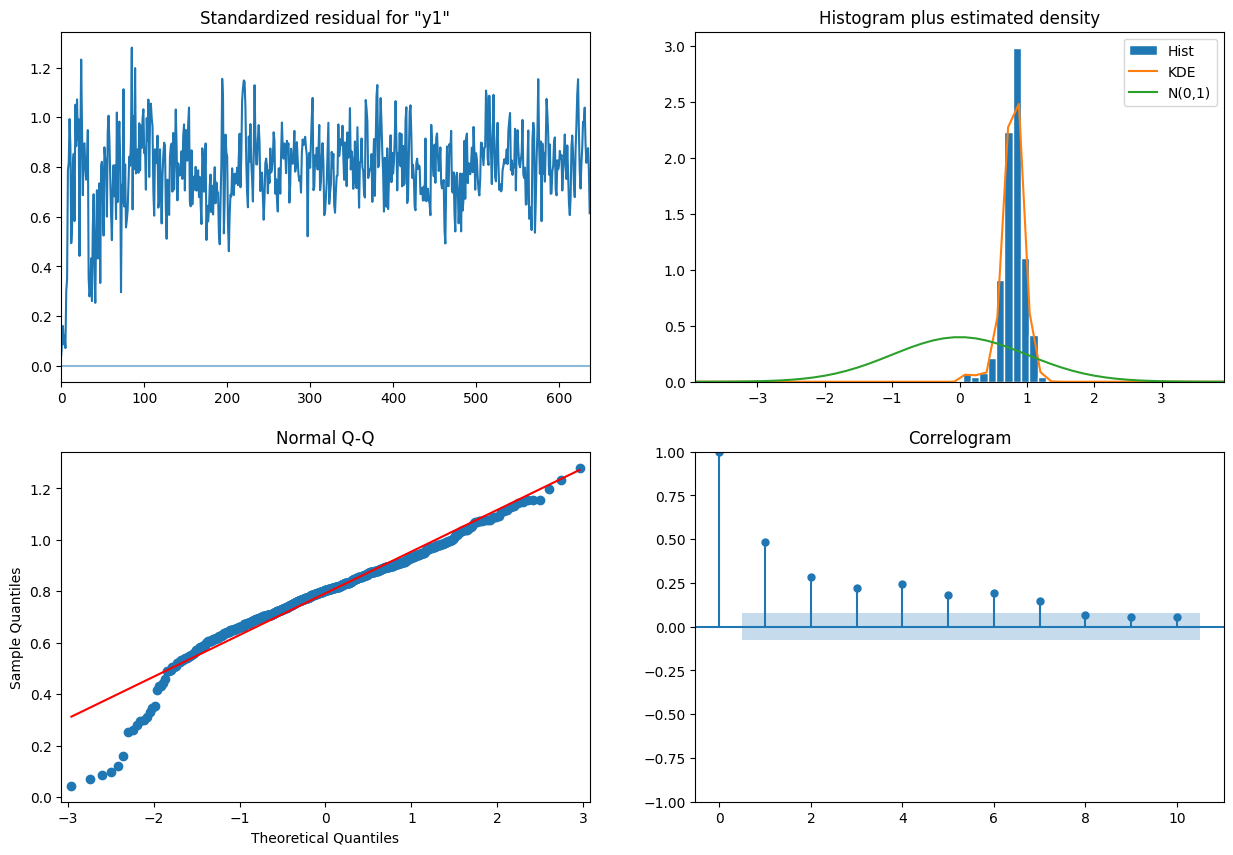

In [23]:
mod = sm.tsa.statespace.SARIMAX(v, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)